# `MissingConeVolumes` - 3D Visual Sanity Check

Visualize 3D training pairs `(carved_x, x)` from the isotropic diffusion dataset. The notebook shows central spatial planes, difference images, and central Fourier planes so the fixed carved missing wedge can be checked before training.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path('/myhome/sdate')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from isodiffusion.datasets import MissingConeVolumes
from isodiffusion.fourier_wedge import build_missing_wedge_mask

import lovely_tensors as lt
lt.monkey_patch()

print('Imports OK')
print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')


import torch


def fft_2D(x, s=None, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    if ortho:
        fft_image = torch.fft.fftn(x, s=s, norm='ortho', dim=dim)
    else:
        fft_image = torch.fft.fftn(x, s=s, dim=dim)
    return torch.fft.fftshift(fft_image, dim=dim)


def ifft_2D(x, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    f_space = torch.fft.ifftshift(x, dim=dim)
    # Perform inverse 2D Fourier Transform
    if ortho:
        return torch.fft.ifftn(f_space, norm='ortho', dim=dim)
    else:
        return torch.fft.ifftn(f_space, dim=dim)


Imports OK
PyTorch 2.8.0+cu128 | CUDA: True


In [2]:
# Configuration
FILE_IDX = 1
RECON_PATH = Path(f'/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction')

# Start with the limited-angle/bad reconstruction or a later iterative estimate.
DATA_PATH = RECON_PATH / f'la_fourier_{FILE_IDX}.npy'
NORM_JSON = RECON_PATH / f'la_fourier_{FILE_IDX}_norm.json'

# Alternative examples:
# DATA_PATH = Path('/myhome/data/sdate/shared/em_data_npy/neuron/synapse-bin4-5i-demo.npy')
# NORM_JSON = DATA_PATH.with_name(DATA_PATH.stem + '_norm.json')

CONE_WIDTH_DEG = 72.0
PATCH_SIZE = 167
TARGET_SIZE = 96
TILT_AXIS = 0
CARVE_CENTER_ANGLE_DEG = 0.0
N_SAMPLES = 10
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_PATH, NORM_JSON

(Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fourier_1.npy'),
 Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fourier_1_norm.json'))

In [3]:
# Normalization is also resolved by the dataset, but loading it here makes plots use raw-value color limits.
if NORM_JSON.exists():
    with open(NORM_JSON) as f:
        norm_cfg = json.load(f)
    norm_min = float(norm_cfg['norm_min'])
    norm_max = float(norm_cfg['norm_max'])
    normalize_range = (norm_min, norm_max)
    print(f'Loaded norm: min={norm_min:.4f}, max={norm_max:.4f}')
else:
    normalize_range = None
    norm_min = norm_max = None
    print('No norm JSON found; dataset will compute p1-p99 normalization.')

def denormalize_fn(x):
    if norm_min is None or norm_max is None:
        return x
    return x * (norm_max - norm_min) + norm_min

Loaded norm: min=-0.0011, max=0.0031


In [4]:
ds = MissingConeVolumes(
    data_path=DATA_PATH,
    cone_width_deg=CONE_WIDTH_DEG,
    patch_size=PATCH_SIZE,
    target_size=TARGET_SIZE,
    normalize_range=normalize_range,
    samples_per_volume=None,
    carve_center_angle_deg=CARVE_CENTER_ANGLE_DEG,
    tilt_axis=TILT_AXIS,
    rotate=True,
)

print(ds)
carved_x0, x0 = ds[0]
print(f'First item: carved_x={tuple(carved_x0.shape)} x={tuple(x0.shape)}')
print(f'Ranges normalized: x=[{x0.min():.4f}, {x0.max():.4f}] carved=[{carved_x0.min():.4f}, {carved_x0.max():.4f}]')

MissingConeVolumes(files=1, total_samples=540, patch_size=167, target_size=96, cone_width_deg=72.0, tilt_axis=0, norm=[-0.001078, 0.003136], rotate=True)
First item: carved_x=(96, 96, 96) x=(96, 96, 96)
Ranges normalized: x=[-0.6305, 1.5358] carved=[-0.4547, 1.5759]


In [5]:
from isodiffusion.fourier_wedge import enforce_known_fourier, apply_missing_wedge


def fourier_guidance(
    source_volume: torch.Tensor,
    vol_init: torch.Tensor,
    timestep: int = 0,
) -> torch.Tensor:
    return enforce_known_fourier(
        estimate_volume=vol_init,
        measured_volume=source_volume.to(vol_init.device, dtype=vol_init.dtype),
        angular_range_deg=CONE_WIDTH_DEG,
        start_angle_deg=CARVE_CENTER_ANGLE_DEG,
        tilt_axis=TILT_AXIS,
    )


guidance_source_volume = x0

def guidance(x_0_raw: torch.Tensor, timestep: int) -> torch.Tensor:
    return fourier_guidance(
        source_volume=guidance_source_volume,
        vol_init=x_0_raw,
        timestep=int(timestep),
    )

print(f'guidance volume shape: {tuple(guidance_source_volume.shape)}')

carved_x0_ = apply_missing_wedge(
    x0,
    angular_range_deg=180 - CONE_WIDTH_DEG,
    start_angle_deg=CARVE_CENTER_ANGLE_DEG +36,
    tilt_axis=TILT_AXIS,
)


guidance volume shape: (96, 96, 96)


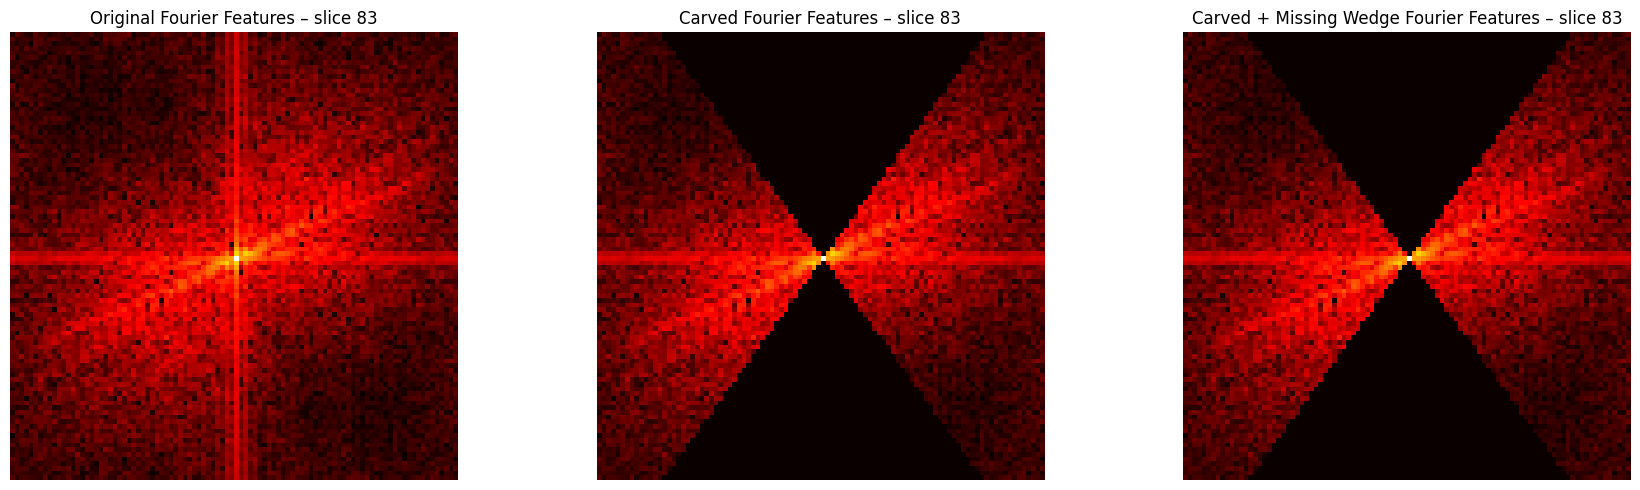

In [6]:
IDX_SLICE = 83
fft_inputs ={
    'Original': x0,
    'Carved': carved_x0,
    'Carved + Missing Wedge': carved_x0_,
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, image) in zip(axes, fft_inputs.items()):
    fft_recon = fft_2D(image)
    magnitude = torch.log1p(torch.abs(fft_recon[IDX_SLICE]))
    ax.imshow(magnitude.cpu().detach(), cmap='hot')
    ax.set_title(f'{title} Fourier Features – slice {IDX_SLICE}')
    ax.axis('off')

plt.tight_layout()
plt.show()

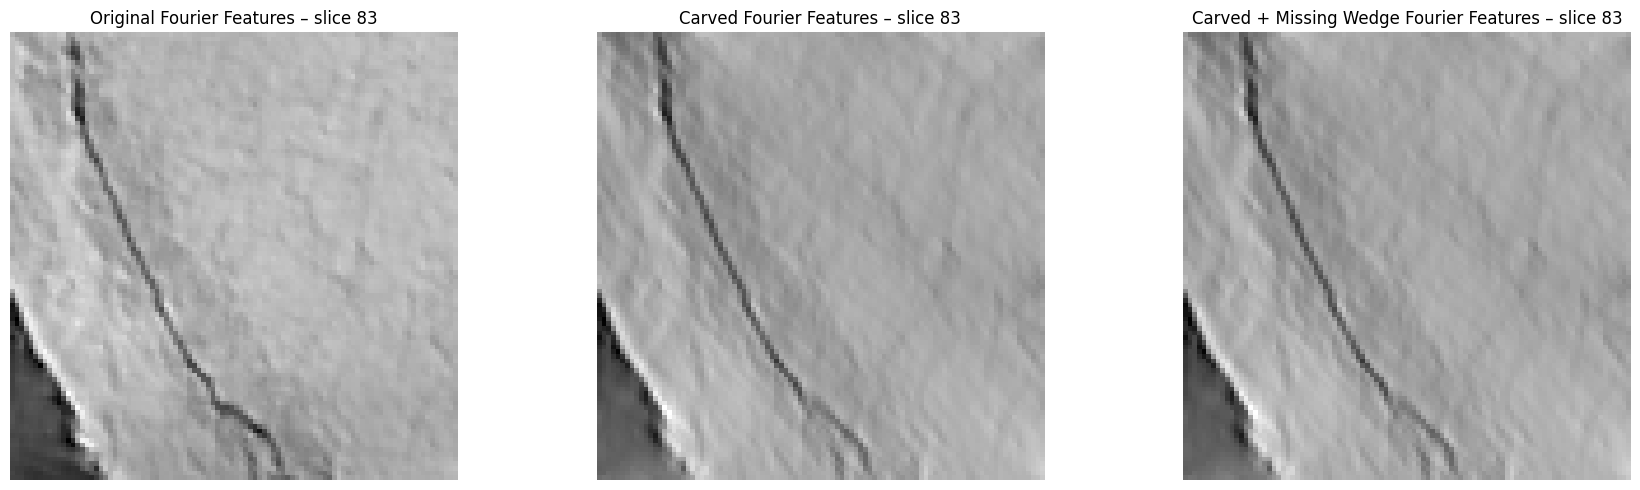

In [7]:
fft_inputs ={
    'Original': x0,
    'Carved': carved_x0,
    'Carved + Missing Wedge': carved_x0_,
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, image) in zip(axes, fft_inputs.items()):
    ax.imshow(image[IDX_SLICE].cpu().detach(), cmap='gray')
    ax.set_title(f'{title} Fourier Features – slice 83')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
def central_planes(vol: torch.Tensor):
    """Return central z, y, x planes from a (D, H, W) volume."""
    d, h, w = vol.shape
    return [vol[d // 2], vol[:, h // 2, :], vol[:, :, w // 2]]


def fft_log_volume(vol: torch.Tensor) -> torch.Tensor:
    F = torch.fft.fftshift(torch.fft.fftn(vol.float()))
    return torch.log1p(F.abs())


def central_wedge_fft_plane(vol: torch.Tensor, tilt_axis: int) -> np.ndarray:
    """Central Fourier plane perpendicular to the tilt axis, where the wedge is visible."""
    mag = fft_log_volume(vol)
    mid = vol.shape[tilt_axis] // 2
    if tilt_axis == 0:
        plane = mag[mid, :, :]
    elif tilt_axis == 1:
        plane = mag[:, mid, :]
    elif tilt_axis == 2:
        plane = mag[:, :, mid]
    else:
        raise ValueError('tilt_axis must be 0, 1, or 2')
    return plane.detach().cpu().numpy()


def central_wedge_mask_plane(shape, cone_width_deg, center_angle_deg, tilt_axis):
    kept_range = 180.0 - cone_width_deg
    start_angle = (center_angle_deg + cone_width_deg / 2.0) % 180.0
    keep_mask = build_missing_wedge_mask(shape, kept_range, start_angle, tilt_axis=tilt_axis)
    missing = (~keep_mask).float()
    mid = shape[tilt_axis] // 2
    if tilt_axis == 0:
        return missing[mid, :, :].numpy()
    if tilt_axis == 1:
        return missing[:, mid, :].numpy()
    return missing[:, :, mid].numpy()


def plot_wedge_edges(ax, center_angle_deg, cone_width_deg, color='cyan'):
    """Draw Friedel-symmetric center and edge rays on a 2D Fourier plane."""
    y_lim = ax.get_ylim()
    x_lim = ax.get_xlim()
    cx = 0.5 * (x_lim[0] + x_lim[1])
    cy = 0.5 * (y_lim[0] + y_lim[1])
    arm = min(abs(x_lim[1] - x_lim[0]), abs(y_lim[1] - y_lim[0])) * 0.42

    for angle, lw, ls in [(center_angle_deg, 2.0, '-'), (center_angle_deg - cone_width_deg / 2, 1.2, '--'), (center_angle_deg + cone_width_deg / 2, 1.2, '--')]:
        rad = np.deg2rad(angle)
        dx = np.cos(rad)
        dy = -np.sin(rad)
        for sign in (+1, -1):
            ax.plot([cx, cx + sign * dx * arm], [cy, cy + sign * dy * arm], color=color, lw=lw, ls=ls, alpha=0.9)


def robust_limits(*volumes, q=(1, 99)):
    arr = np.concatenate([v.detach().cpu().numpy().ravel() for v in volumes])
    return np.percentile(arr, q)

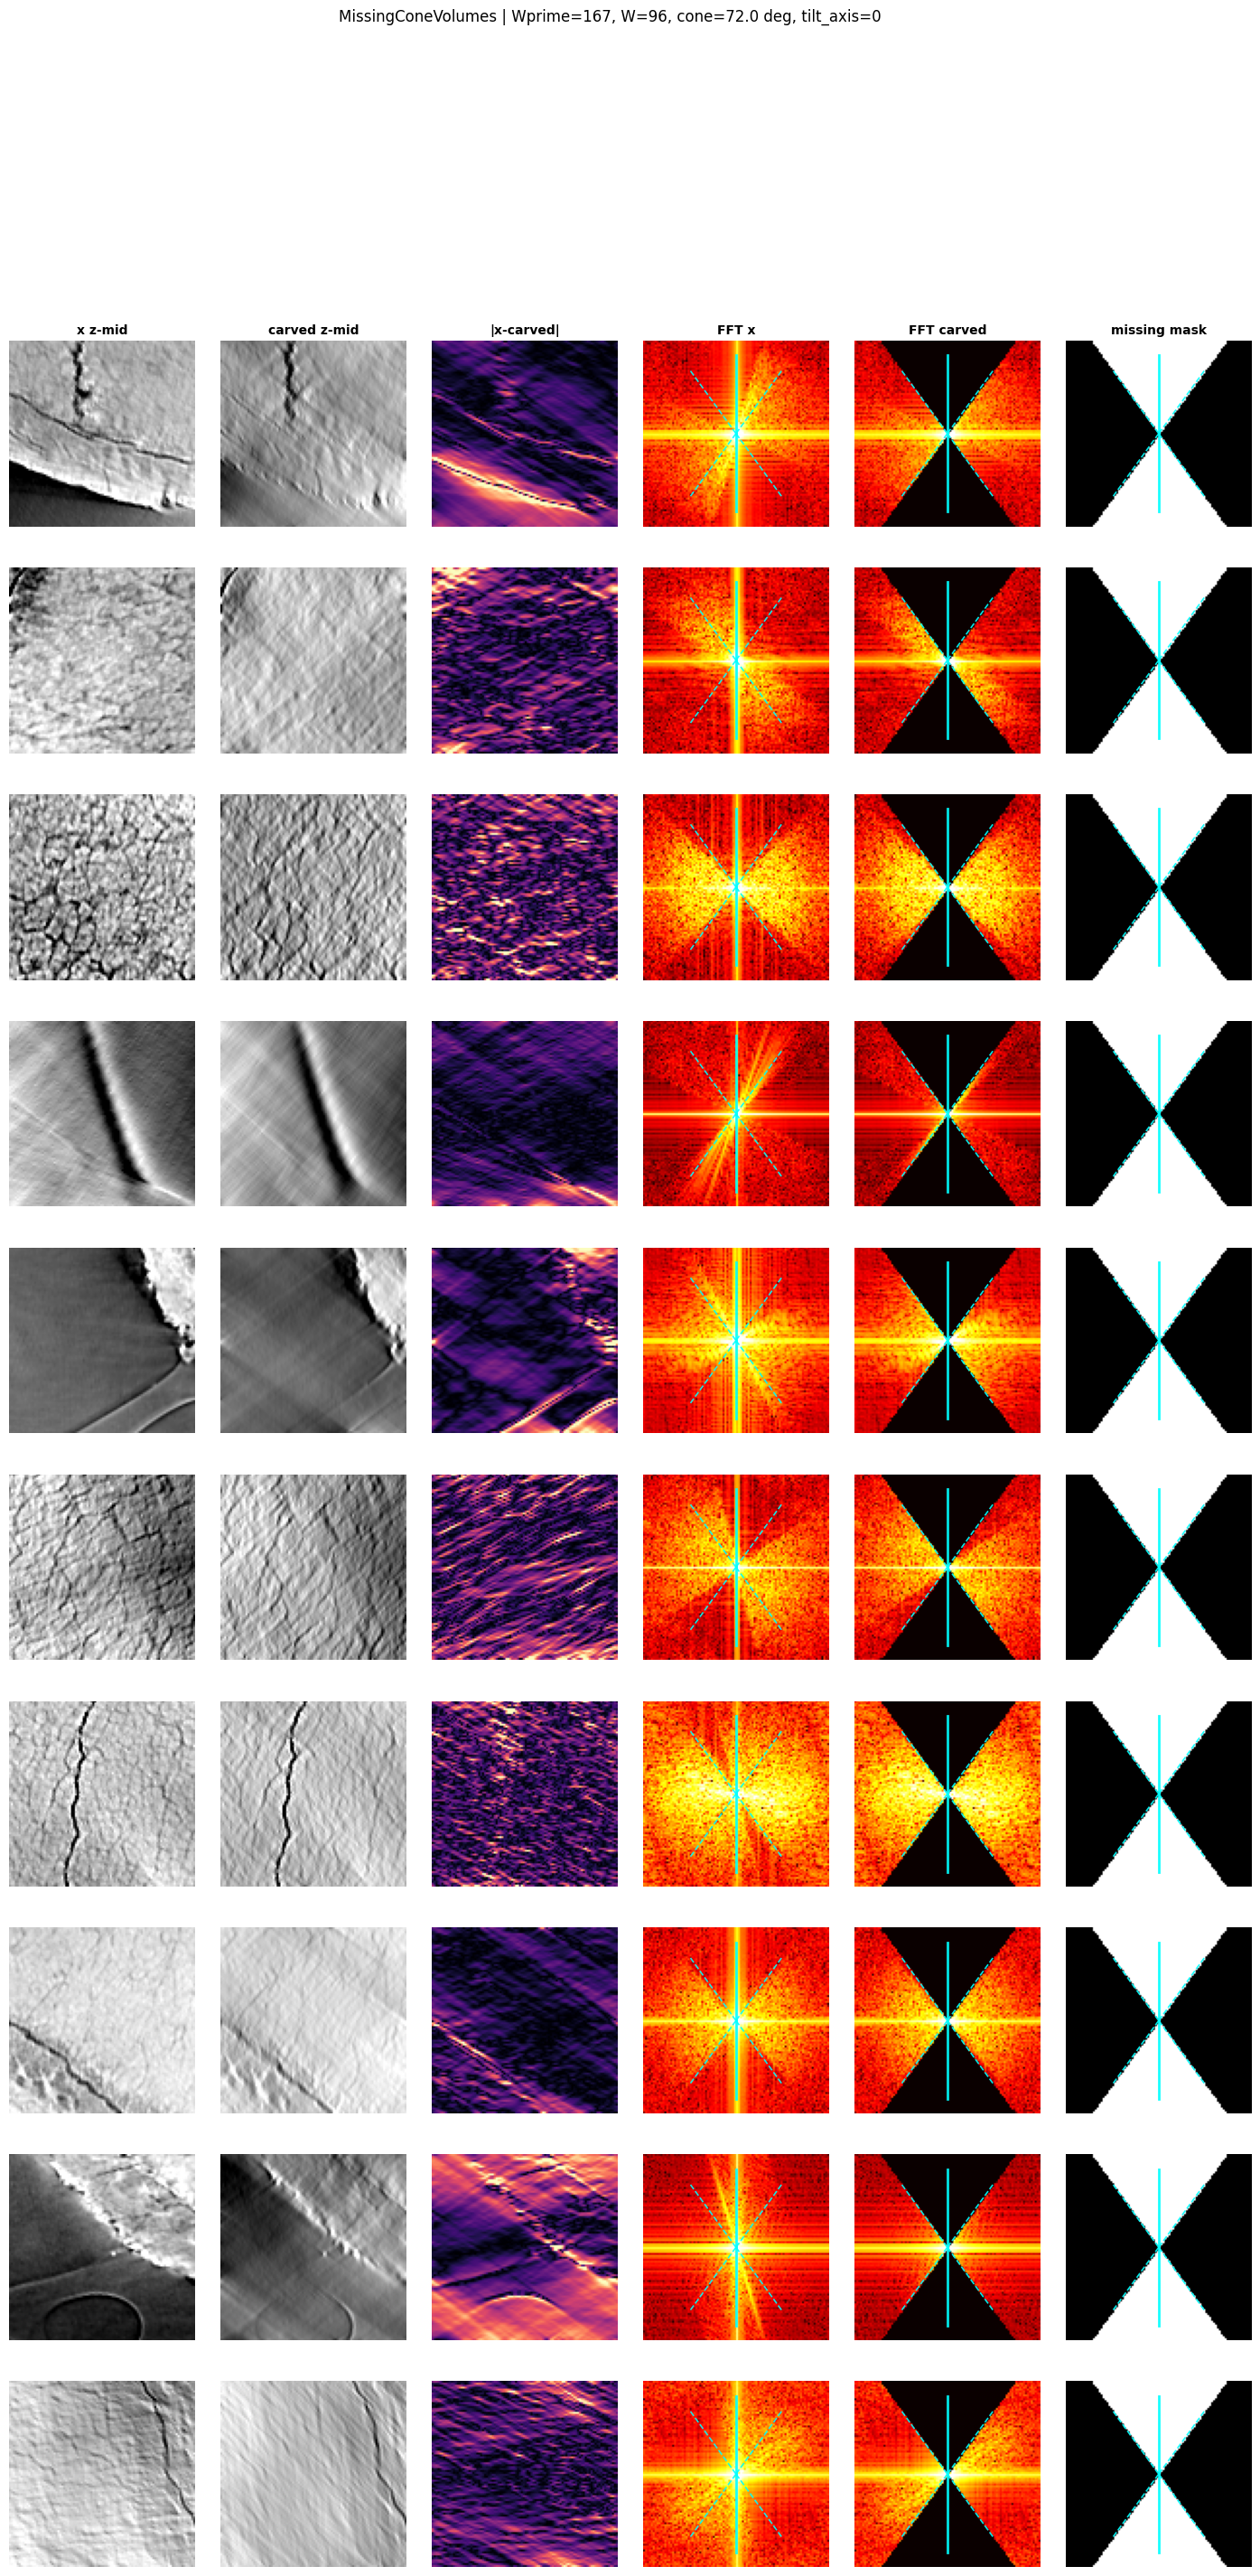

: 

In [ ]:
# A compact multi-sample grid: central spatial slice plus Fourier wedge plane.
indices = torch.randperm(len(ds))[:N_SAMPLES].tolist()

fig, axes = plt.subplots(N_SAMPLES, 6, figsize=(18, 3.2 * N_SAMPLES), gridspec_kw={'wspace': 0.04, 'hspace': 0.22})
if N_SAMPLES == 1:
    axes = axes[np.newaxis, :]

headers = ['x z-mid', 'carved z-mid', '|x-carved|', 'FFT x', 'FFT carved', 'missing mask']
for col, title in enumerate(headers):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')

mask_plane = central_wedge_mask_plane((TARGET_SIZE, TARGET_SIZE, TARGET_SIZE), CONE_WIDTH_DEG, CARVE_CENTER_ANGLE_DEG, TILT_AXIS)

for row, idx in enumerate(indices):
    carved_x, x = ds[idx]
    x_raw = denormalize_fn(x)
    carved_raw = denormalize_fn(carved_x)
    diff = (x_raw - carved_raw).abs()
    vmin, vmax = robust_limits(x_raw, carved_raw)
    dmax = np.percentile(diff.numpy(), 99)

    spatial_images = [x_raw[TARGET_SIZE // 2], carved_raw[TARGET_SIZE // 2], diff[TARGET_SIZE // 2]]
    cmaps = ['gray', 'gray', 'magma']
    limits = [(vmin, vmax), (vmin, vmax), (0, dmax)]
    for col, (img, cmap, lim) in enumerate(zip(spatial_images, cmaps, limits)):
        axes[row, col].imshow(img.numpy(), cmap=cmap, vmin=lim[0], vmax=lim[1])
        axes[row, col].axis('off')

    fft_x = central_wedge_fft_plane(x, TILT_AXIS)
    fft_carved = central_wedge_fft_plane(carved_x, TILT_AXIS)
    fmin, fmax = np.percentile(np.concatenate([fft_x.ravel(), fft_carved.ravel()]), [1, 99.7])
    for col, fft_img in [(3, fft_x), (4, fft_carved)]:
        axes[row, col].imshow(fft_img, cmap='hot', vmin=fmin, vmax=fmax)
        plot_wedge_edges(axes[row, col], CARVE_CENTER_ANGLE_DEG + 90, CONE_WIDTH_DEG)
        axes[row, col].axis('off')

    axes[row, 5].imshow(mask_plane, cmap='gray')
    plot_wedge_edges(axes[row, 5], CARVE_CENTER_ANGLE_DEG + 90, CONE_WIDTH_DEG)
    axes[row, 5].axis('off')
    axes[row, 0].set_ylabel(f'idx {idx}', fontsize=9)

plt.suptitle(f'MissingConeVolumes | Wprime={PATCH_SIZE}, W={TARGET_SIZE}, cone={CONE_WIDTH_DEG} deg, tilt_axis={TILT_AXIS}', y=0.995)
plt.show()

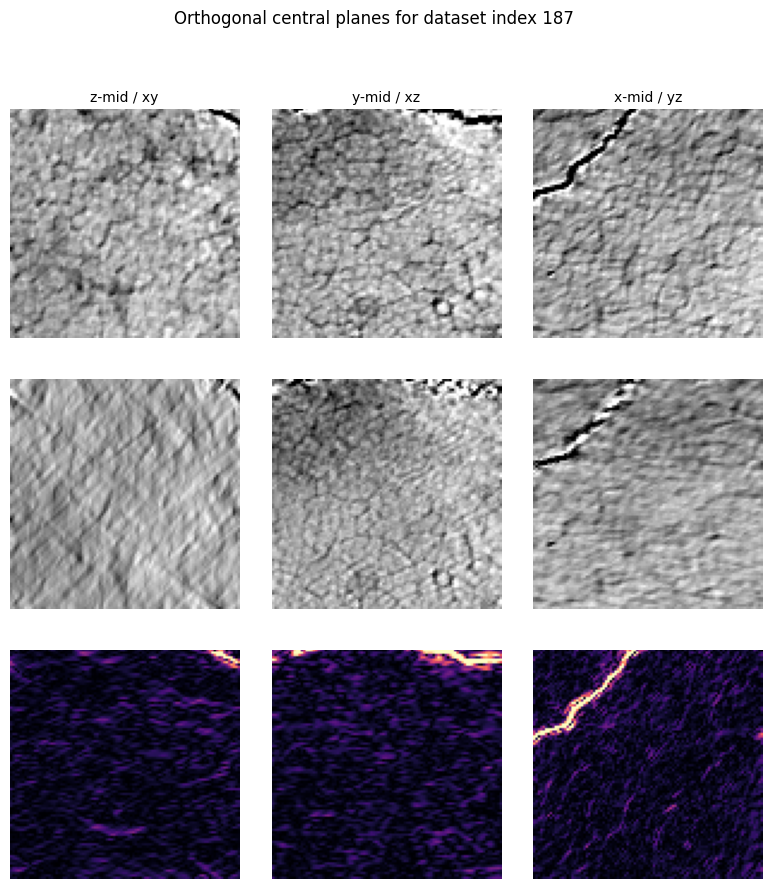

In [10]:
# Detailed view for one sample: all three orthogonal central planes for x, carved_x, and their difference.
sample_idx = indices[0]
carved_x, x = ds[sample_idx]
x_raw = denormalize_fn(x)
carved_raw = denormalize_fn(carved_x)
diff = (x_raw - carved_raw).abs()
vmin, vmax = robust_limits(x_raw, carved_raw)
dmax = np.percentile(diff.numpy(), 99)

plane_names = ['z-mid / xy', 'y-mid / xz', 'x-mid / yz']
rows = [('x', x_raw, 'gray', (vmin, vmax)), ('carved_x', carved_raw, 'gray', (vmin, vmax)), ('|x-carved|', diff, 'magma', (0, dmax))]

fig, axes = plt.subplots(3, 3, figsize=(10, 10), gridspec_kw={'wspace': 0.04, 'hspace': 0.18})
for r, (row_name, vol, cmap, lim) in enumerate(rows):
    for c, plane in enumerate(central_planes(vol)):
        axes[r, c].imshow(plane.numpy(), cmap=cmap, vmin=lim[0], vmax=lim[1])
        axes[r, c].axis('off')
        if r == 0:
            axes[r, c].set_title(plane_names[c], fontsize=10)
        if c == 0:
            axes[r, c].set_ylabel(row_name, fontsize=10)

plt.suptitle(f'Orthogonal central planes for dataset index {sample_idx}')
plt.show()

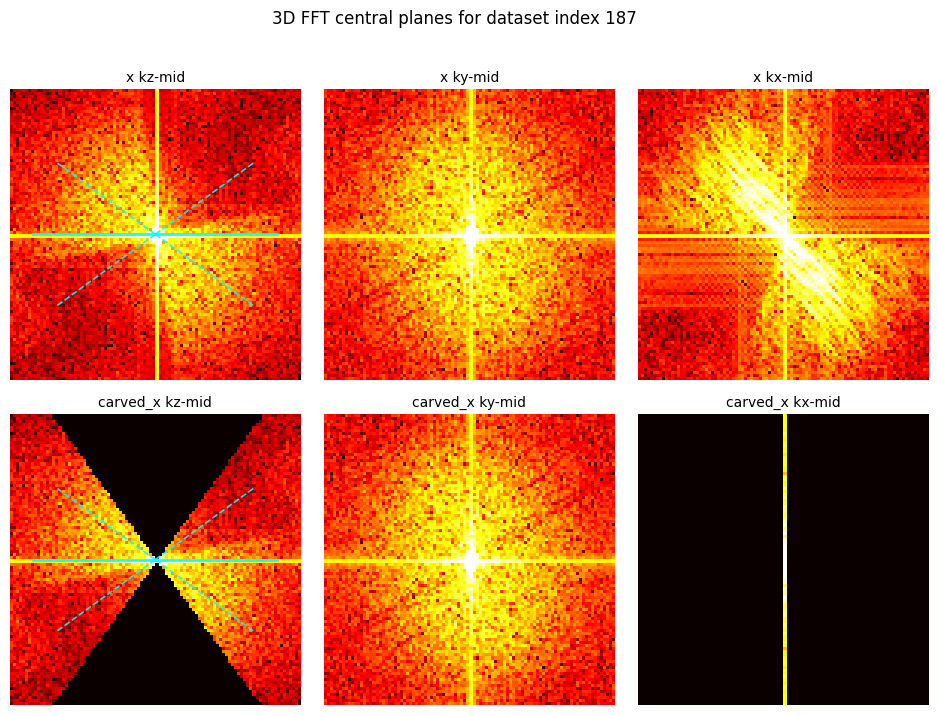

In [11]:
# Fourier detail: central planes of the 3D FFT along each axis.
def fft_central_planes(vol):
    mag = fft_log_volume(vol)
    d, h, w = mag.shape
    return [mag[d // 2].numpy(), mag[:, h // 2, :].numpy(), mag[:, :, w // 2].numpy()]

fft_x_planes = fft_central_planes(x)
fft_carved_planes = fft_central_planes(carved_x)
fmin, fmax = np.percentile(np.concatenate([p.ravel() for p in fft_x_planes + fft_carved_planes]), [1, 99.7])

fig, axes = plt.subplots(2, 3, figsize=(12, 8), gridspec_kw={'wspace': 0.04, 'hspace': 0.12})
for c, name in enumerate(['kz-mid', 'ky-mid', 'kx-mid']):
    axes[0, c].imshow(fft_x_planes[c], cmap='hot', vmin=fmin, vmax=fmax)
    axes[0, c].set_title(f'x {name}', fontsize=10)
    axes[0, c].axis('off')
    axes[1, c].imshow(fft_carved_planes[c], cmap='hot', vmin=fmin, vmax=fmax)
    axes[1, c].set_title(f'carved_x {name}', fontsize=10)
    axes[1, c].axis('off')

# The wedge overlay belongs on the plane perpendicular to TILT_AXIS.
plot_col = TILT_AXIS
plot_wedge_edges(axes[0, plot_col], CARVE_CENTER_ANGLE_DEG, CONE_WIDTH_DEG)
plot_wedge_edges(axes[1, plot_col], CARVE_CENTER_ANGLE_DEG, CONE_WIDTH_DEG)

plt.suptitle(f'3D FFT central planes for dataset index {sample_idx}')
plt.show()

In [12]:
# Per-sample stats: useful for checking that carving changes the patch and does not create NaNs.
print(f"{'idx':>8} {'x range':>24} {'carved range':>24} {'mean |diff|':>14} {'max |diff|':>14} {'finite':>8}")
print('-' * 100)
for idx in indices:
    carved_x, x = ds[idx]
    diff = (x - carved_x).abs()
    finite = torch.isfinite(x).all().item() and torch.isfinite(carved_x).all().item()
    print(
        f"{idx:8d} "
        f"[{x.min():8.4f}, {x.max():8.4f}] "
        f"[{carved_x.min():8.4f}, {carved_x.max():8.4f}] "
        f"{diff.mean():14.6f} {diff.max():14.6f} {str(finite):>8}"
    )

     idx                  x range             carved range    mean |diff|     max |diff|   finite
----------------------------------------------------------------------------------------------------
     187 [ -0.3009,   1.3010] [ -0.2622,   1.2770]       0.024300       0.509039     True
     144 [ -0.3041,   1.2249] [ -0.3344,   1.2208]       0.020391       0.376527     True
     249 [ -0.4155,   1.2009] [ -0.3747,   1.2868]       0.025607       0.669332     True
     216 [ -0.4929,   1.4289] [ -0.4884,   1.3806]       0.028087       0.680778     True
     377 [  0.1132,   1.0735] [  0.1660,   1.0291]       0.021189       0.266517     True
     126 [ -0.7247,   1.4891] [ -0.7922,   1.5280]       0.051068       0.649382     True
     150 [ -0.2156,   1.7161] [ -0.3565,   1.4865]       0.021788       0.809988     True
     327 [ -0.1095,   1.1062] [  0.0482,   1.1929]       0.023473       0.529367     True
     290 [  0.4073,   0.9884] [  0.4919,   0.9506]       0.021320       0.198125 